# Assignment #
## Andres Arias
### Z23987588

## 1. Load datasets in csv format
### Edges

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random

# I'm using this path because I have the data in my local machine amd working with VS Code, you can change it to your own path
path_1 = '/Users/andresarias/Documents/FAU/SocialNetworks_BigData/Assignment_1/data/edges.csv'
edges = pd.read_csv(path_1, sep=',')
edges.head(5)

,id_0,id_1
0,76M2Ekj8bG8W7X2nbx2CpF,7sfl4Xt5KmfyDs2T3SVSMK
1,0hk4xVujcyOr6USD95wcWb,7Do8se3ZoaVqUt3woqqSrD
2,38jpuy3yt3QIxQ8Fn1HTeJ,4csQIMQm6vI2A2SCVDuM2z
3,6PvcxssrQ0QaJVaBWHD07l,6UCQYrcJ6wab6gnQ89OJFh
4,2R1QrQqWuw3IjoP5dXRFjt,4mk1ScvOUkuQzzCZpT6bc0


### Nodes

In [2]:
path_2 = '/Users/andresarias/Documents/FAU/SocialNetworks_BigData/Assignment_1/data/nodes.csv'
nodes = pd.read_csv(path_2, sep=',')
nodes.head(5)

,spotify_id,name,followers,popularity,genres,chart_hits
0,48WvrUGoijadXXCsGocwM4,Byklubben,1738.0,24,"['nordic house', 'russelater']",['no (3)']
1,4lDiJcOJ2GLCK6p9q5BgfK,Kontra K,1999676.0,72,"['christlicher rap', 'german hip hop']","['at (44)', 'de (111)', 'lu (22)', 'ch (31)', ..."
2,652XIvIBNGg3C0KIGEJWit,Maxim,34596.0,36,[],['de (1)']
3,3dXC1YPbnQPsfHPVkm1ipj,Christopher Martin,249233.0,52,"['dancehall', 'lovers rock', 'modern reggae', ...","['at (1)', 'de (1)']"
4,74terC9ol9zMo8rfzhSOiG,Jakob Hellman,21193.0,39,"['classic swedish pop', 'norrbotten indie', 's...",['se (6)']


## Creating the graph

In [3]:
G = nx.from_pandas_edgelist(edges, source='id_0', target='id_1')
print(G)

Graph with 153327 nodes and 300386 edges


# 2. Visualize the graph

I chose BFS because it explores the network level by level, allowing me to obtain nodes that are progressively farther from the starting node. This method provides a structured way to create a connected sample while preserving the local neighborhood structure of the original network. 

I chose a sample size of 5,000 nodes because it is within the required 5,000–10,000 range while keeping computationally intensive analyses, such as shortest path calculations, manageable for my pc.

In [4]:
# Choosing a random node to start
random.seed(42)
start_node = random.choice(list(G.nodes))

# I selected BFS for my assignment
bfs_tree = nx.bfs_tree(G, source=start_node)

# Sample of 5k first nodes from the BFS tree
sample_nodes = list(bfs_tree.nodes)[:5000]

# Creating the subgraph with the sampled nodes
G_sample = G.subgraph(sample_nodes).copy()

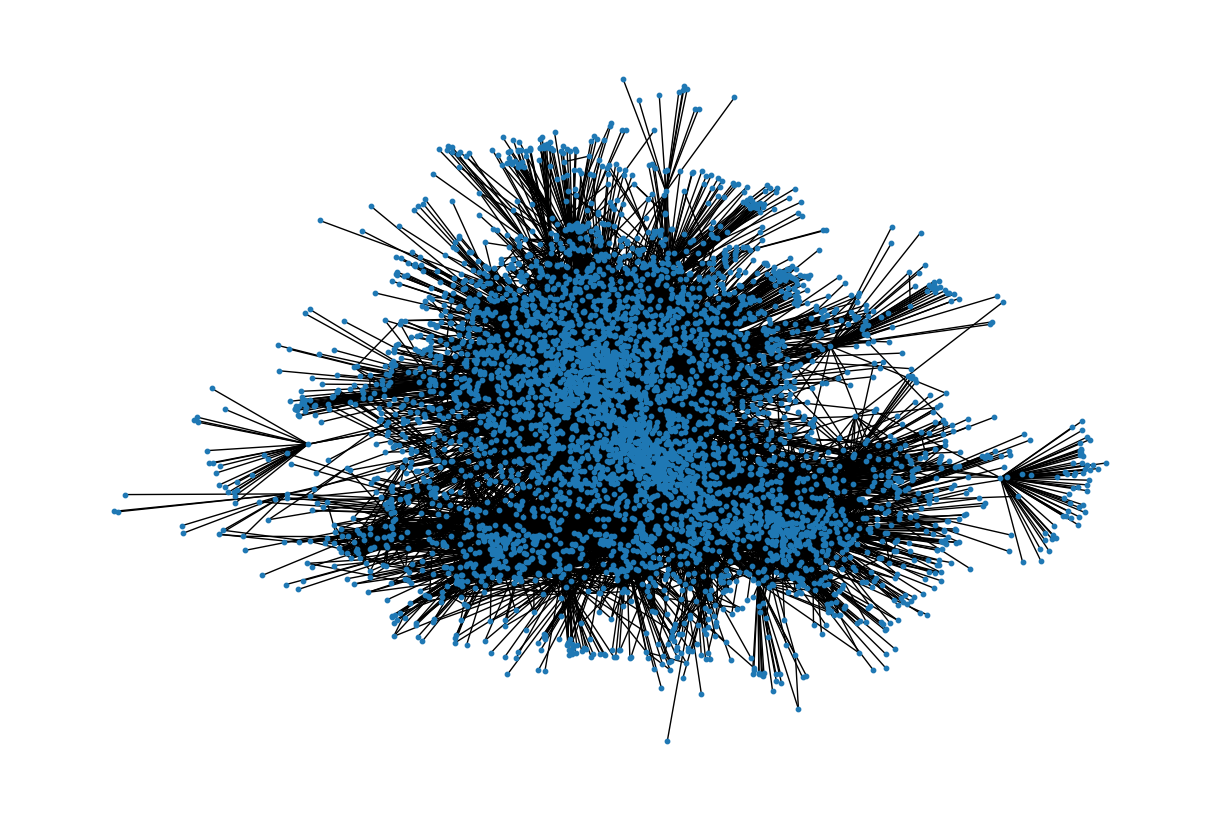

In [5]:
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_sample, seed=42)
nx.draw(G_sample, pos, node_size=10, with_labels=False)
plt.show()

# 3 & 4	Calculate the number of nodes and edges in the graph


In [6]:
print("Initial node", start_node)
print("Nodes:", G_sample.number_of_nodes())
print("Edges", G_sample.number_of_edges())

Initial node 2Z1nXVYB6tke5IsWSLI7lw
Nodes: 5000
Edges 22836


# 5. Calculate the network diameter

In [7]:
# Biggest shortest path length between any two nodes
diameter = nx.diameter(G_sample)
print("Network diameter:", diameter)

Network diameter: 6


# 6. Add a markdown cell. In your own words, interpret the meaning of the obtained value for network diameter

The diameter shows the largest path among the shortest path between all nodes within the network. For my case I have a subgraph with 5000 nodes and my diameter with this seed is 6. It means, even for the two nodes that are farthest apart in the network, the shortest path between them requires at most 6 edges. Therefore, the nodes in this subgraph are relatively close to each other in terms of network connections.

# 7. Plot a histogram representing degree distribution

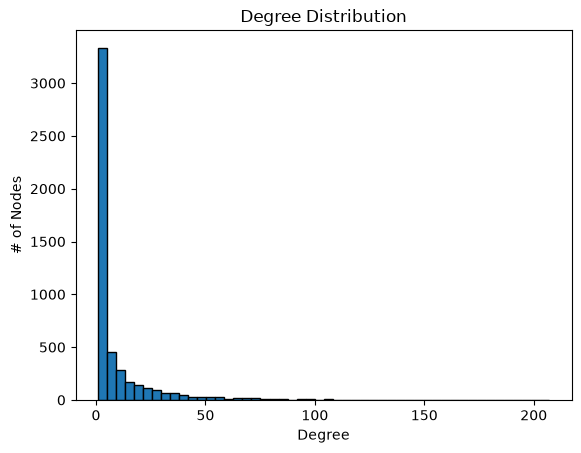

In [8]:
# Degree distribution, using a list comprehension to get the degree of each node in the sampled graph
degrees = [degree for node, degree in G_sample.degree()]

# Plotting the degree distribution
plt.hist(degrees, bins=50, edgecolor='black') #Adjusting bins to 50 for better visualization - distribution of degrees
plt.xlabel("Degree") 
plt.ylabel("# of Nodes")
plt.title("Degree Distribution")
plt.show()

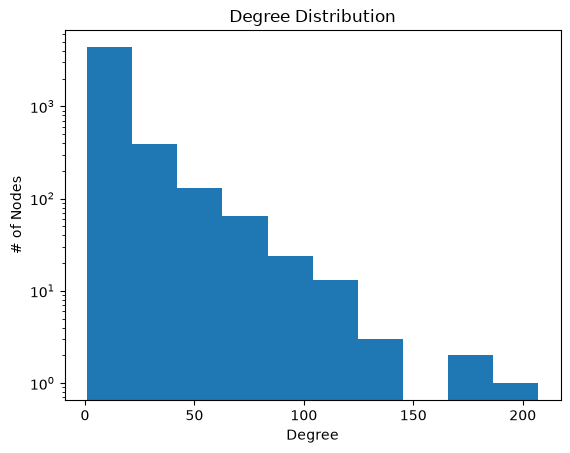

In [9]:
plt.hist(degrees)
plt.yscale('log') # I added this line because original plot was difficult to read when I plotted it the first time
plt.xlabel("Degree") 
plt.ylabel("# of Nodes")
plt.title("Degree Distribution")
plt.show()

# 8. Add a markdown cell and discuss what you observe by looking at the generated degree distribution

Most observations have relatively low degree values, while only a small number of nodes have much higher degree values.

In [10]:
deg = np.array(degrees)

# Number of nodes in each degree range
rangos = [(1, 2), (3, 5), (6, 10), (11, 20), (21, 50), (51, 100), (101, None)]

for lo, hi in rangos:
    n = ((deg >= lo) & (deg <= hi)).sum() if hi else (deg >= lo).sum()
    etiqueta = f"{lo}-{hi}" if hi else f"{lo}+"
    print("degree %-7s %4d nodes (%4.1f%%)" % (etiqueta + ":", n, 100 * n / len(deg)))


degree 1-2:    2488 nodes (49.8%)
degree 3-5:     845 nodes (16.9%)
degree 6-10:    543 nodes (10.9%)
degree 11-20:   473 nodes ( 9.5%)
degree 21-50:   475 nodes ( 9.5%)
degree 51-100:  155 nodes ( 3.1%)
degree 101+:     21 nodes ( 0.4%)


With this visualization I check that most of the nodes have just 1-2 connections, so, probably it means that this nodes are a close path (death end), probably due to BFS subgraph but I must check that, while we have nodes (>30%) with a bigger degree (+6) that works as reference points to connect all the network. Getting this way a short diameter for a big subgraph.

It is related with the method I selected for my assignment (BFS), that shows certain level of depth for this subgraph, so, actually is not a good description for the entire graph, just for this subgraph.

# 9. Calculate the average degree of a node.

In [11]:
degrees = [degree for node, degree in G_sample.degree()] # Same line from past cells
average_degree = np.mean(degrees)
print("Average degree:", average_degree)

Average degree: 9.1344


# 10. Add a markdown cell. In your own words, explain what the obtained average degree of a node mean in the context of this dataset?

It means that on average each node of my dataset-subgraph has 9 coonnections with others nodes, but... analyzing the last cells I saw that a big amount of nodes (majority) has just 1-2 connections (50%), so, maybe the average is not a good measure for this question, due to some ranges of nodes >50 degree (probably outliers, to prove it we need a boxplot, so, its just a suspicion) that directly affect the average. Also, if we look the histogram we can appreciate that we dont have a normal distribution, so, average is not a representative measure. For this case I would use the median.

# 11. Calculate the average shortest path length between any two nodes.

In [12]:
# Average shortest path length for my subgraph
average_shortest_path = nx.average_shortest_path_length(G_sample)
print("Average shortest path length:", average_shortest_path)

Average shortest path length: 3.934033846769354


In [13]:
# The full graph is not connected (1339 components) and computing the exact
# average shortest path length would require a BFS from each of the148k nodes.
# Instead I estimate it using a random sample of source nodes
gcc = G.subgraph(max(nx.connected_components(G), key=len)).copy()

random.seed(7)
n_sources = 60
sources = random.sample(list(gcc.nodes()), n_sources)

total = count = 0
for u in sources:
    for v, d in nx.single_source_shortest_path_length(gcc, u).items():
        if u != v:
            total += d
            count += 1

estimated_aspl = total / count
print("Giant component: %d nodes, %d edges" % (gcc.number_of_nodes(), gcc.number_of_edges()))
print("Estimated average shortest path length (sample of %d source nodes): %.2f" % (n_sources, estimated_aspl))


Giant component: 148386 nodes, 296770 edges
Estimated average shortest path length (sample of 60 source nodes): 6.15


# 12. Add a markdown cell. In your own words, explain what the obtained value of the average shortest path length means in the context of this dataset.

It means that if I want to connect two nodes within this dataset network finding the shortest path, the average length would be 4 edges. As I checked, the diameter for this subgraph is 6 edges, so, an average of 4 it's a reasonable measure, taking into account the amount of nodes with a death end in this dataset. 

All of this show my subgraph node actually are relatively close to each other although it's a big network of 5000 nodes. But... again, i'm pretty sure this is due the BFS I selected for my assignment. This method explore it throw levels and that's why I have this scenario with an average of 4 (3.93) edges for the shortest paths between 2 nodes. Also, I calculated the average shortest path for a bigger sample of the entire graph, confirming that the BFS has a big influence with this aswer main point

# 13. Plot the distribution of shortest path length.

## This cell below was taken from the class notebooks

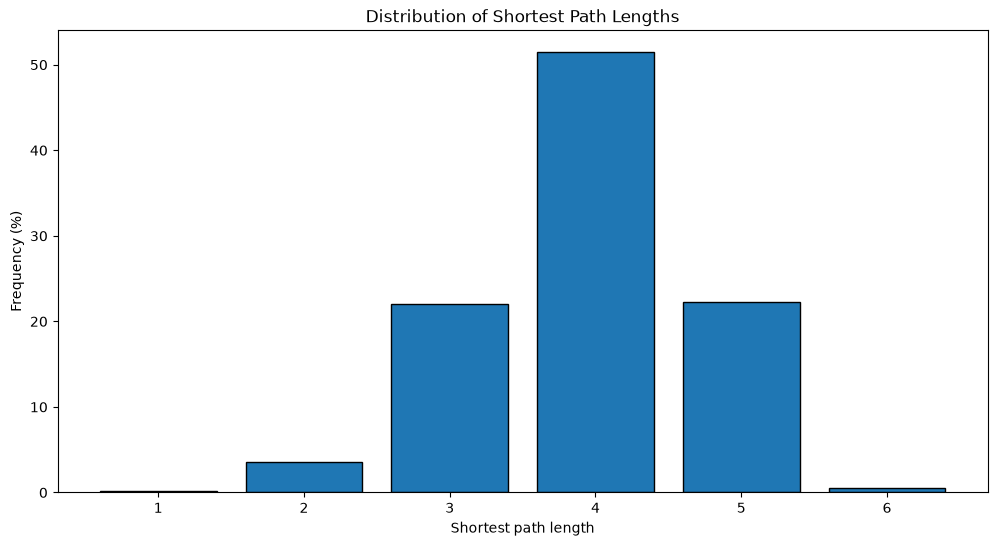

[ 0.18272454  3.61769954 22.03015803 51.42894979 22.26382076  0.47664733]


In [14]:
# all_pairs_shortest_path_length returns a dict-of-dicts mapping each node u to
# the distance to every other node. Same approach used in the Lecture 5 notebook.
shortest_path_lengths = dict(nx.all_pairs_shortest_path_length(G_sample))

# We know the maximum shortest path length (the diameter), so create an array
# to store values from 0 up to (and including) diameter
path_lengths = np.zeros(diameter + 1, dtype=int)

# Extract the frequency of shortest path lengths between two nodes
for pls in shortest_path_lengths.values():
    pl, cnts = np.unique(list(pls.values()), return_counts=True)
    path_lengths[pl] += cnts

# Express frequency distribution as a percentage (ignoring path lengths of 0)
freq_percent = 100 * path_lengths[1:] / path_lengths[1:].sum()

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(np.arange(1, diameter + 1), height=freq_percent, edgecolor='black')
ax.set_xlabel("Shortest path length")
ax.set_ylabel("Frequency (%)")
ax.set_title("Distribution of Shortest Path Lengths")
plt.show()

print(freq_percent)

## I tried using other path and looking for documentation

In [15]:
import collections
path_lengths = collections.Counter()

for node in G_sample.nodes(): # Iterate over each node in the sampled graph
    distances = nx.single_source_shortest_path_length(G_sample, node) # Calculate shortest path lengths from the current node to all other nodes
    for target, d in distances.items(): # Iterate over the distances from the source node to all other nodes
        if node != target: # Avoid counting the distance from a node to itself
            path_lengths[d] += 1


In [16]:
path_lengths

Counter({4: 12854666, 5: 5564842, 3: 5506438, 2: 904244, 6: 119138, 1: 45672})

For this point I used the following official documentation
- collections.Counter: https://docs.python.org/3/library/collections.html#collections.Counter
- networkx.single_source_shortest_path_length: https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.shortest_paths.unweighted.single_source_shortest_path_length.html
- networkx.Graph.nodes: https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.nodes.html
- matplotlib.pyplot.bar: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html
- sorted (built-in): https://docs.python.org/3/library/functions.html#sorted

I used a Counter instead of building a list with all 25 million distances, since only
the frequency of each distance is needed for the histogram. The distances are computed
with one BFS per node, the same operation that all_pairs_shortest_path_length performs.


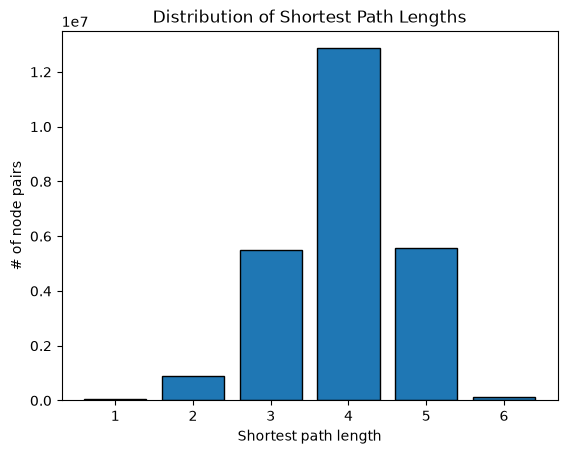

In [17]:
lengths = sorted(path_lengths) # [1, 2, 3, 4, 5, 6]
counts  = [path_lengths[d] for d in lengths] # How many node pairs are at each distance

plt.bar(lengths, counts, edgecolor='black')
plt.xlabel("Shortest path length")
plt.ylabel("# of node pairs")
plt.title("Distribution of Shortest Path Lengths")
plt.show()


# 14. Add a markdown cell and explain what you observe in this histogram.

This histogram shows the distribution of shortest path distances between the nodes of G_sample. Each bar indicates how many node pairs have a specific minimum distance. In this case, a distance of 4 is the most frequent as we verified in the last cells, meaning that the majority of node pairs are connected by a shortest path of approximately 4 hops.

I also see a good distribution of the shortest paths, similar to a normal distribution, so, it confirms that average its a good representative measure for this problem

# 15. Calculate the edge density of this graph

In [18]:
edge_density = nx.density(G_sample)
print("Edge density:", edge_density)

Edge density: 0.001827245449089818


# 16. Add a markdown cell and answer the following question. What can we conclude about this graph considering its edge density? 

As we checked in the questions related with average degree, this graph has a lot of nodes between the range of 1-5 degree (66%) in a subgraph with 5000 nodes. Edge density measures the proportion of actual edges in the graph compared to the maximum number of possible edges it could have.. So, having a very low degree confirms that the edge density would be extremely low. BFS for my case gave me a good density zone within the subgraph but also we have death end nodes that affect this measure, taking into account that good connected nodes has small proportion of connections compared with total of posibilities.

# 17. Calculate the global clustering coefficient of this graph

In [19]:
global_clustering = nx.transitivity(G_sample)
print("Global clustering coefficient:", global_clustering)

Global clustering coefficient: 0.14423629114782613


# 18. Add a markdown cell and answer the following question. What can we conclude about this graph considering its global clustering coefficient?

For this graph it indicates that it has a global clustering coefficient of 0.14, which means that there is a certain tendency for connected nodes to form triplets or triangles, compared to the expectations of the edge density, that show a graph with a minium proportion of connections compared with the total. 

At the beginning when I analyzed degree of nodes it appears as a very isolated subgraph with some specific paths to reach each node. Then with the last cells I discovered a high degree zone in the center of the graph with nodes with a higher edge density. So, it makes sense thinking these triplets are more concentrated in this zone of the subgraph. Here I found the concept of small world that fit perfect with my subgraph, short shortest paths and a big clustering. In this case I consider clustering is very high because the edge density its considerably smaller.

For our dataset context it has a high level of interactions between artists, revealing that there exist some close communities within the network, especially in this part of the subgraph.

That's why the diameter is just 6 edges. Because the center of the graph contains a lot of shortcuts that allow us to reach each node of the network coming from this center zone, which represents some artists with a big influence.

# 19. Calculate the number of connected components in the graph

In [20]:
connected_components = nx.number_connected_components(G_sample)
print("N of connected components:", connected_components)


N of connected components: 1


The analyzed subgraph has 1 connected component. This means that all 5000 of its nodes are connected either directly or indirectly by a path.

This result is consistent with the selection process using BFS, as this method explores nodes reachable from a starting node. However, it does not necessarily represent the entire original graph, which contains multiple disconnected components.

# 20. Load the node attribute file and display the first few rows of the dataset

### Nodes

In [21]:
path_2 = '/Users/andresarias/Documents/FAU/SocialNetworks_BigData/Assignment_1/data/nodes.csv'
nodes = pd.read_csv(path_2, sep=',')
nodes.head(5)

,spotify_id,name,followers,popularity,genres,chart_hits
0,48WvrUGoijadXXCsGocwM4,Byklubben,1738.0,24,"['nordic house', 'russelater']",['no (3)']
1,4lDiJcOJ2GLCK6p9q5BgfK,Kontra K,1999676.0,72,"['christlicher rap', 'german hip hop']","['at (44)', 'de (111)', 'lu (22)', 'ch (31)', ..."
2,652XIvIBNGg3C0KIGEJWit,Maxim,34596.0,36,[],['de (1)']
3,3dXC1YPbnQPsfHPVkm1ipj,Christopher Martin,249233.0,52,"['dancehall', 'lovers rock', 'modern reggae', ...","['at (1)', 'de (1)']"
4,74terC9ol9zMo8rfzhSOiG,Jakob Hellman,21193.0,39,"['classic swedish pop', 'norrbotten indie', 's...",['se (6)']


# 21. Plot a histogram of the followers variable. 

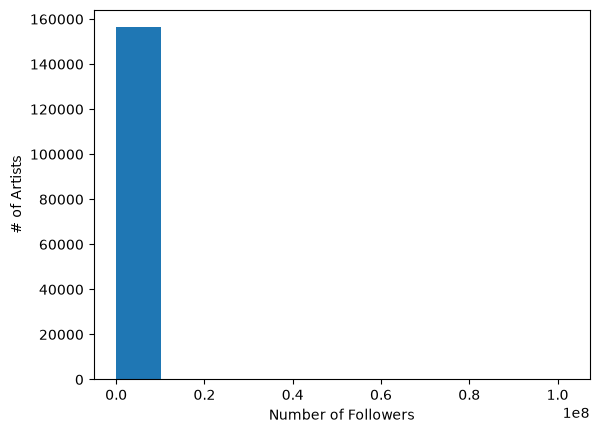

In [22]:
plt.hist(nodes['followers'])
plt.xlabel("Number of Followers")
plt.ylabel("# of Artists")
plt.show()

This histo is not useful. So hard to read and practically don't say nothing

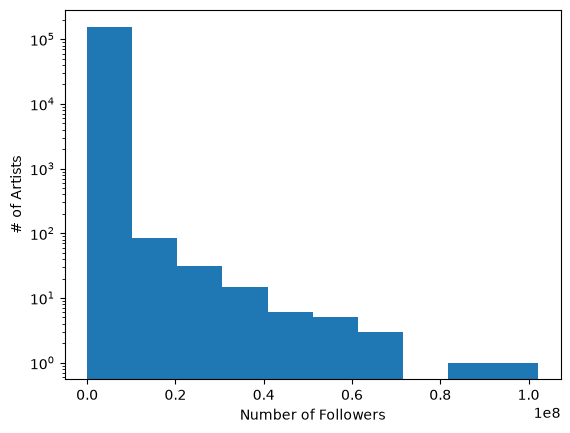

In [23]:
plt.hist(nodes['followers'])
plt.yscale('log') # I added this line because original plot was difficult to read when I plotted it the first time
plt.xlabel("Degree") 
plt.xlabel("Number of Followers")
plt.ylabel("# of Artists")
plt.show()

# 22. Add a markdown cell and describe the distribution. Is it symmetric, skewed, and does it contain outliers? 

It shows a big distribution of users with a small number of followers and a few users with a very large number of followers. So, this is clearly a skewed distribution, which is common in social networks where a small number of users (influencers) have a disproportionately large number of followers compared to the majority of users.
If we look at the histogram, we appreciate that the majority of users have a relatively poor number of followers, making the distribution skewed in the first bar, so far from a normal distribution or a Gaussian bell curve.

About Outliers I wanna check it by my side...

In [24]:
print("Average followers:", nodes['followers'].mean())
print("Median followers:", nodes['followers'].median())

Average followers: 86223.71295503076
Median followers: 363.0


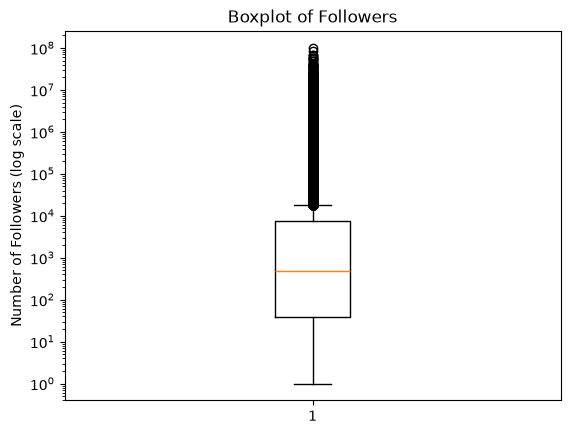

In [25]:
# boxplot does not ignore NaN, and zeros cannot be shown on a log scale, i fix that first
followers = nodes['followers'].dropna()
followers_positive = followers[followers > 0]

plt.boxplot(followers_positive)
plt.yscale('log')
plt.ylabel("Number of Followers (log scale)")
plt.title("Boxplot of Followers")
plt.show()

It confirms that we have 'outliers' in terms of math that can affect a distribution analysis. But.. in real life it's normal that an user has this amount of followers (influencer, sportman, politician, artist in this dataset etc) So, dropping outliers would depend on the type of analysis we want to execute, but this outliers are normal.

# 23. Plot a histogram of the popularity variable

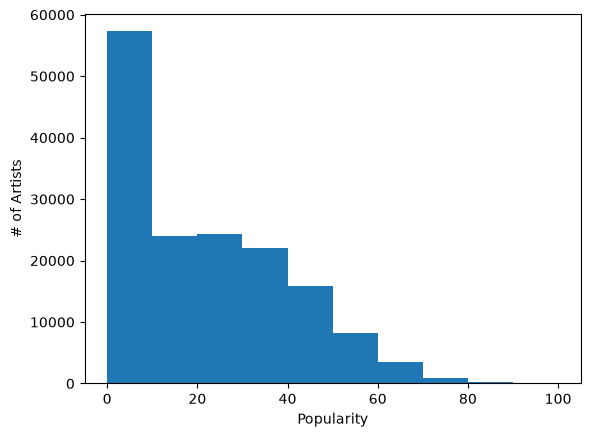

In [26]:
plt.hist(nodes['popularity'])
plt.xlabel("Popularity")
plt.ylabel("# of Artists")
plt.show()

# 24. Add a markdown cell and describe the distribution. Is it symmetric, skewed, and does it contain outliers? 

In [27]:
print("Average popularity:", nodes['popularity'].mean())
print("Median popularity:", nodes['popularity'].median())

Average popularity: 21.157497027272377
Median popularity: 18.0


For this case we have a skewed distribution again. Here we have a scale within the popularity with a roof in 100. Again I checked the mayority of users have a popularity of 0-20 because many users are not artists, are classified as "unknown artists," or may represent less established artists.

Checking the median and the average I confirmed its a little skewed distribution because the median and the average are close beteween them.

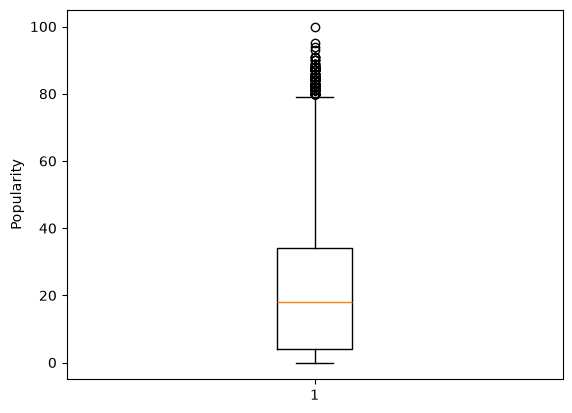

In [28]:
# boxplot does not ignore NaN and zeros cannot be shown on a log scale, i fix that first
popularity = nodes['popularity'].dropna()

plt.boxplot(popularity)
plt.ylabel("Popularity")
plt.show()

The boxplot also shows that most observations are concentrated at lower popularity values, while some users have considerably higher scores and we have some outliers in the roof, surpassing the high limit. Following the last case, there artist with a high popularity that are completely normal but if you mixed it with the avergae user would be an outlier. These higher values contribute to the tail of the distribution and may influence the average.

By comparing the mean and the median, I can get a better idea of the distribution's shape. If the mean is slightly higher than the median, this is consistent with a right skewed distribution, where a smaller number of highly popular users pull the average upward.

# 25. Create a bar plot showing the number of artists with popularity of 0-25, 25-50, 50-75 and 75-100. 

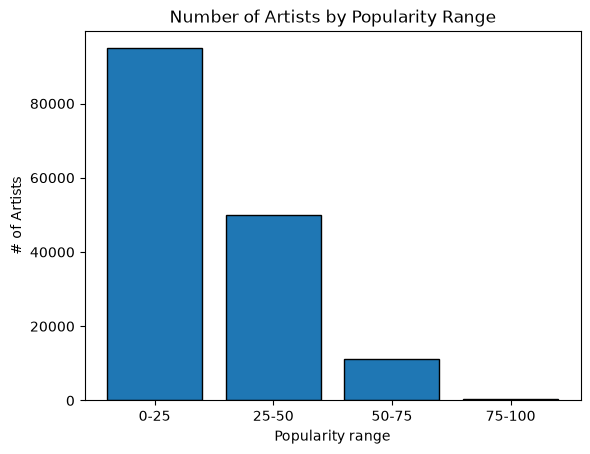

popularity
0-25      94827
25-50     49884
50-75     11308
75-100      403
Name: count, dtype: int64


In [29]:
# The ranges given overlap at 25, 50 and 75, so I use intervals closed on the
# right (0-25], (25-50], (50-75], (75-100], including 0 in the first one.

labels = ['0-25', '25-50', '50-75', '75-100']
groups = pd.cut(nodes['popularity'], bins=[0, 25, 50, 75, 100],
                labels=labels, include_lowest=True)
counts = groups.value_counts().reindex(labels)

plt.bar(counts.index, counts.values, edgecolor='black')
plt.xlabel("Popularity range")
plt.ylabel("# of Artists")
plt.title("Number of Artists by Popularity Range")
plt.show()

print(counts)


# 26. Add a markdown cell and interpret the proportion of artists according to popularity in this dataset

It makes sense according with my personal appreciation and the real motor of Spotify. There are a few artists thar everybody knows and consume their music. There are other ones more popular inside a music genre, country or type of community.

0-25 (60%) We have small or amateur artists that are starting in this world, have a small audience or doi it just for fun. Here we have tha mayority of artists.

25-50 (32%) There are more important artists, probably inside a music genre or popular in their communities.

50-75 (7%) More known artists that maybe have international impact for many people

75-100 (0.26%) More succesful artists that everybody knows for their impact in music. There are so popular than people that don't know about music even know them.

Overall, the distribution shows a very clear concentration of artists in the lower popularity ranges. The proportion decreases substantially as popularity increases, going from 60.62% in the 0–25 range to only 0.26% in the 75–100 range. This creates a pyramid-like distribution in which highly popular artists represent only a small fraction of the total population.


# 27. Create a bar plot showing the number of artists in the top 5 most prevalent genres in the dataset. 

In [30]:
nodes.info()

<class 'pandas.DataFrame'>
RangeIndex: 156422 entries, 0 to 156421
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   spotify_id  156422 non-null  str    
 1   name        156418 non-null  str    
 2   followers   156418 non-null  float64
 3   popularity  156422 non-null  int64  
 4   genres      156422 non-null  str    
 5   chart_hits  19641 non-null   str    
dtypes: float64(1), int64(1), str(4)
memory usage: 7.2 MB


The genres column is stored as text that looks like a list, "['pop', 'rock']".
ast.literal_eval turns that text into a real Python list and explode() puts each
genre on its own row so they can be counted individually.

source: https://stackoverflow.com/questions/52232742/how-to-use-ast-literal-eval-in-a-pandas-dataframe-and-handle-exceptions

In [31]:
import ast
nodes['genres_list'] = nodes['genres'].apply(ast.literal_eval) # Convert genres column into a list of genres
genres_exploded = nodes.explode('genres_list') # Explode the list of genres into separate rows
genres_exploded

,spotify_id,name,followers,popularity,genres,chart_hits,genres_list
0,48WvrUGoijadXXCsGocwM4,Byklubben,1738.0,24,"['nordic house', 'russelater']",['no (3)'],nordic house
0,48WvrUGoijadXXCsGocwM4,Byklubben,1738.0,24,"['nordic house', 'russelater']",['no (3)'],russelater
1,4lDiJcOJ2GLCK6p9q5BgfK,Kontra K,1999676.0,72,"['christlicher rap', 'german hip hop']","['at (44)', 'de (111)', 'lu (22)', 'ch (31)', ...",christlicher rap
1,4lDiJcOJ2GLCK6p9q5BgfK,Kontra K,1999676.0,72,"['christlicher rap', 'german hip hop']","['at (44)', 'de (111)', 'lu (22)', 'ch (31)', ...",german hip hop
2,652XIvIBNGg3C0KIGEJWit,Maxim,34596.0,36,[],['de (1)'],NaN
...,...,...,...,...,...,...,...
156417,2ces6d2YsQP1RpGMYpdFy8,David Urwitz,5470.0,29,['classic swedish pop'],NaN,classic swedish pop
156418,6AeznZajNbXUulT7W4tK5l,Darmiko,2022.0,23,[],NaN,NaN
156419,3GEijIjrgb4lPe9WtURBzz,Katriell,268.0,0,[],NaN,NaN
156420,0ldQL0icSoMz9OOZcWG8Zt,Yung Fresh,181.0,19,[],NaN,NaN


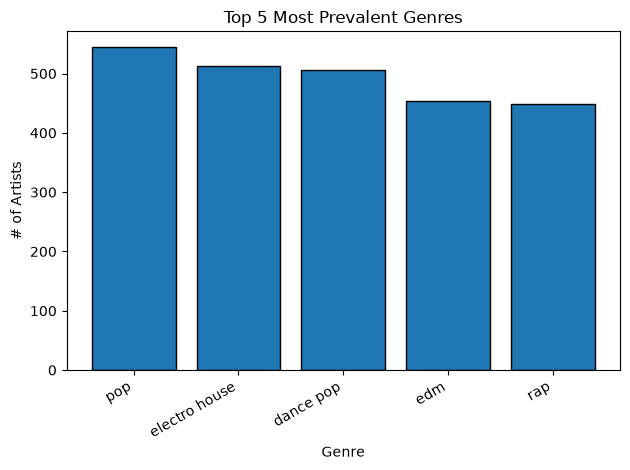

genres_list
pop              544
electro house    513
dance pop        506
edm              453
rap              448
Name: count, dtype: int64


In [32]:
top5 = genres_exploded['genres_list'].value_counts().head(5)

plt.bar(top5.index, top5.values, edgecolor='black')
plt.xlabel("Genre")
plt.ylabel("# of Artists")
plt.title("Top 5 Most Prevalent Genres")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(top5)

In [33]:
nodes.shape

(156422, 7)

# 28. Add a markdown cell and interpret the results

In [34]:
genre_counts = genres_exploded['genres_list'].value_counts()
print("Distinct genres:", genre_counts.size)
print("Genres with only 1 artist:", (genre_counts == 1).sum())
print("Genres with 5 or fewer artists:", (genre_counts <= 5).sum())

Distinct genres: 4853
Genres with only 1 artist: 759
Genres with 5 or fewer artists: 2249


In [35]:
no_genre = (nodes['genres_list'].apply(len) == 0).sum()
print("\nArtists with no genre listed: %d (%.1f%%)" % (no_genre, 100 * no_genre / len(nodes)))


Artists with no genre listed: 102133 (65.3%)


In [36]:
for kw in ['pop', 'rap', 'hip hop', 'house', 'rock']:
    variants = genre_counts[genre_counts.index.str.contains(kw, na=False)]
    print("  '%s': %d distinct labels, %d artists in total" % (kw, variants.size, variants.sum()))

  'pop': 498 distinct labels, 24655 artists in total
  'rap': 284 distinct labels, 12328 artists in total
  'hip hop': 201 distinct labels, 9973 artists in total
  'house': 91 distinct labels, 5116 artists in total
  'rock': 310 distinct labels, 6558 artists in total


This bar plot shows a curious thing, during a first looking we see a top 5 with some of the most popular genres actually, those everybody knows, that is not new. But... I confirmed that the top 1 have a very low frecuency compared to the .shape this dataset has. So, checking more deeply I identified that a lot of artist don't have a associated genre (empty list) and between the current genres there's a lot of mini variations in the name.

1. 65% of artists don't have a genre listed
2. There are 759 genres that have one artist listed
3. Each common genre has a lot of different variations within the data, so we would require a data cleaning to improve the accuracy, one example it's pop that has variations as 'pop', 'dance pop', etc

So, I didnt' see a common chart, it's rare because the top 1 just have 500 items in a big dataset

# 29. Create a boxplot comparing popularity per 5 most prevalent genres

For this point I was looking info here:
- pandas.Index.tolist: https://pandas.pydata.org/docs/reference/api/pandas.Index.tolist.html
- pandas.Series.isin: https://pandas.pydata.org/docs/reference/api/pandas.Series.isin.html
- pandas.Series.value_counts: https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html
- pandas.DataFrame.explode: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.explode.html
- matplotlib.pyplot.boxplot: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html
- ast.literal_eval: https://docs.python.org/3/library/ast.html#ast.literal_eval


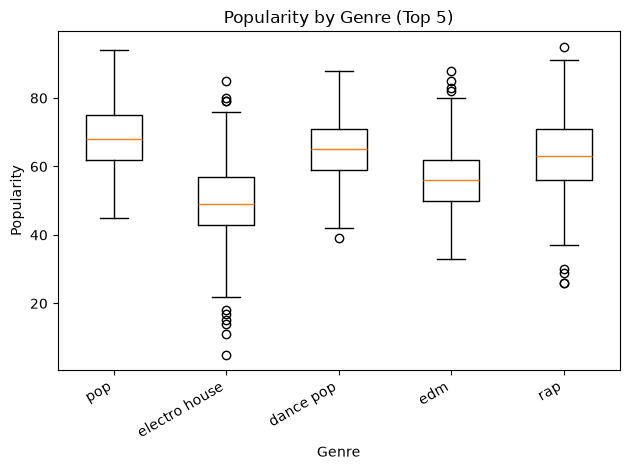

In [37]:
top5_genres = top5.index.tolist() #top 5 is the variable for point 28

# Keep only the rows whose genre is one of the top 5
subset = genres_exploded[genres_exploded['genres_list'].isin(top5_genres)]

data = [subset[subset['genres_list'] == g]['popularity'].values for g in top5_genres]

plt.boxplot(data, tick_labels=top5_genres)
plt.ylabel("Popularity")
plt.xlabel("Genre")
plt.title("Popularity by Genre (Top 5)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# 30. Add a markdown cell and discuss whether artist popularity differs based on the genre

Artist popularity does differ based on the genre. The pop box (62-75) and the electro house box (43-57) don't overlap, with 19 points of difference between their medians. However pop, dance pop and rap overlap between them, so its not that every genre is different but that there are two blocks. 

The song genres at the top and the electronic ones at the bottom. There are a few genres with outliers, except for pop that actually is the top 1. It means that pop populariy is consistent due to the absence of outliers. Rap, however, shows the widest interquartile range with outliers at both extremes (ranging from 26 to 95) suggesting the coexistence of a small group of highly popular artists with limited reach. 

At the other end its electro house that has the lowest median (49) and the highest number of low outliers, some close to 5 indicating a more uneven catalog with many unknown artists